# Conjunto de Datos de Predicción del Clima

Este conjunto de datos fue creado con fines de enseñanza y entrenamiento en aprendizaje automático y aprendizaje profundo.  
Se puede utilizar para tareas de clasificación, regresión y pronóstico.  
Es lo suficientemente complejo para demostrar problemas realistas como sobreajuste y datos desbalanceados, manteniendo una estructura intuitiva y accesible.  

## **Origen de los Datos**  

Los datos originales fueron tomados de:

**EUROPEAN CLIMATE ASSESSMENT & DATASET (ECA&D)**, archivo creado el 22-04-2021.  
Estos datos pueden utilizarse libremente siempre que se reconozca la siguiente fuente:  

*Klein Tank, A.M.G. y coautores, 2002. Conjunto de datos diarios de temperatura del aire en superficie y series de precipitación del siglo XX para la Evaluación Climática Europea.*  
*International Journal of Climatology, 22, 1441-1453.*  
**Datos y metadatos disponibles en:** [http://www.ecad.eu](http://www.ecad.eu)  

---

## **Selección y Procesamiento de los Datos**  

Los datos meteorológicos iniciales fueron obtenidos del proyecto ECA&D [1], que proporciona observaciones diarias de estaciones meteorológicas en Europa y el Mediterráneo. Se seleccionaron 18 ciudades o localidades europeas con múltiples observaciones diarias disponibles entre los años 2000 y 2010:

- **Suiza:** Basel  
- **Hungría:** Budapest  
- **Alemania:** Dresden, Düsseldorf, Kassel, München  
- **Países Bajos:** De Bilt, Maastricht  
- **Reino Unido:** Heathrow  
- **Eslovenia:** Ljubljana  
- **Suecia:** Malmo, Estocolmo  
- **Francia:** Montélimar, Perpignan, Tours  
- **Noruega:** Oslo  
- **Italia:** Roma  
- **Austria:** Sonnblick  

Las observaciones meteorológicas diarias para estas 18 localidades abarcan diferentes períodos. Algunas incluyen registros desde el siglo XIX, pero para este conjunto de datos solo se consideraron registros entre **2000 y 2010**, resultando en **3654 observaciones diarias**.  

El conjunto de datos incluye múltiples variables:  

- Todas las localidades contienen registros de **temperatura media, temperatura máxima y temperatura mínima**.  
- Se incluyen otras variables como **cobertura nubosa, velocidad del viento, ráfagas de viento, humedad, presión, radiación global, precipitación y horas de sol**, siempre que los datos estuvieran disponibles.  

### **Limpieza y Transformación de Datos**  

1. Se eliminaron columnas con más del **5% de valores inválidos** ("-9999").  
2. Para columnas con hasta **5% de valores inválidos**, los valores faltantes fueron reemplazados por el valor promedio.  
3. El resultado final incluye **165 variables** a lo largo de **3654 días**.  
4. Se realizaron transformaciones de unidades para normalizar los rangos de valores, facilitando su uso en modelos de aprendizaje automático.  

A pesar de estas transformaciones, se decidió **no estandarizar completamente los datos** para mantener la interpretación intuitiva de las unidades.  

Las unidades finales son:  
- **Temperatura**: grados Celsius  
- **Velocidad del viento y ráfagas**: metros por segundo (m/s)  
- **Humedad**: fracción de 100%  
- **Presión**: 1000 hPa  
- **Radiación global**: 100 W/m²  
- **Precipitación**: centímetros  
- **Horas de sol**: horas  

---

## **Unidades Físicas de las Variables**  

| Código | Descripción | Unidad Original | Unidad Convertida |
|--------|------------|-----------------|------------------|
| CC     | Cobertura nubosa | oktas | oktas |
| DD     | Dirección del viento | grados | grados |
| FG     | Velocidad del viento | 0.1 m/s | 1 m/s |
| FX     | Ráfaga de viento | 0.1 m/s | 1 m/s |
| HU     | Humedad | 1% | fracción de 100% |
| PP     | Presión a nivel del mar | 0.1 hPa | 1000 hPa |
| QQ     | Radiación global | W/m² | 100 W/m² |
| RR     | Precipitación | 0.1 mm | 10 mm |
| SS     | Horas de sol | 0.1 horas | 1 hora |
| TG     | Temperatura media | 0.1 °C | °C |
| TN     | Temperatura mínima | 0.1 °C | °C |
| TX     | Temperatura máxima | 0.1 °C | °C |

---


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import pandas as pd
import numpy as np


In [5]:
df = pd.read_csv("weather_prediction_dataset.csv", encoding='ISO-8859-1')

df

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-9.3,0.7,1.6,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,0.5,2.0,2.0,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-1.0,2.8,3.4,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,2.5,4.6,4.9,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-1.8,2.9,3.6,0.95,1.0209,0.39,0.04,8.0,6.4,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649,20091228,12,7,0.82,1.0084,0.28,0.42,0.3,3.2,1.0,...,-2.7,2.4,3.7,0.95,1.0011,0.22,1.50,6.2,1.8,10.6
3650,20091229,12,7,0.92,1.0028,0.22,1.68,0.2,4.5,2.4,...,-9.5,0.8,5.3,0.89,0.9966,0.24,0.40,10.4,6.2,14.5
3651,20091230,12,8,0.92,0.9979,0.07,1.54,0.0,8.5,7.5,...,-12.5,-7.4,3.8,0.88,0.9939,0.24,1.00,10.0,8.7,11.3
3652,20091231,12,7,0.93,0.9958,0.17,0.57,0.1,6.6,4.3,...,-9.3,-6.5,4.2,0.88,0.9933,0.58,0.02,8.5,6.2,10.9


In [7]:
# Ver las columnas del dataset
print(df.columns)

Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity',
       'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation',
       'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min',
       ...
       'STOCKHOLM_temp_min', 'STOCKHOLM_temp_max', 'TOURS_wind_speed',
       'TOURS_humidity', 'TOURS_pressure', 'TOURS_global_radiation',
       'TOURS_precipitation', 'TOURS_temp_mean', 'TOURS_temp_min',
       'TOURS_temp_max'],
      dtype='object', length=165)


In [11]:
print(len(df.columns))  # Muestra cuántas columnas tiene el DataFrame


165


In [14]:
print(df.columns.tolist())  # Convierte el índice de columnas en una lista


['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation', 'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max', 'BUDAPEST_cloud_cover', 'BUDAPEST_humidity', 'BUDAPEST_pressure', 'BUDAPEST_global_radiation', 'BUDAPEST_precipitation', 'BUDAPEST_sunshine', 'BUDAPEST_temp_mean', 'BUDAPEST_temp_max', 'DE_BILT_cloud_cover', 'DE_BILT_wind_speed', 'DE_BILT_wind_gust', 'DE_BILT_humidity', 'DE_BILT_pressure', 'DE_BILT_global_radiation', 'DE_BILT_precipitation', 'DE_BILT_sunshine', 'DE_BILT_temp_mean', 'DE_BILT_temp_min', 'DE_BILT_temp_max', 'DRESDEN_cloud_cover', 'DRESDEN_wind_speed', 'DRESDEN_wind_gust', 'DRESDEN_humidity', 'DRESDEN_global_radiation', 'DRESDEN_precipitation', 'DRESDEN_sunshine', 'DRESDEN_temp_mean', 'DRESDEN_temp_min', 'DRESDEN_temp_max', 'DUSSELDORF_cloud_cover', 'DUSSELDORF_wind_speed', 'DUSSELDORF_wind_gust', 'DUSSELDORF_humidity', 'DUSSELDORF_pressure', 'DUSSELDORF_global_radiation', 'DUSSE

In [25]:

# Cargar el dataset (reemplaza 'weather_prediction_dataset.csv' con tu archivo real)
df = pd.read_csv("weather_prediction_dataset.csv", encoding='ISO-8859-1')

# Crear diccionarios de DataFrames por cada ubicación
locations = {
    "Basel": df[["DATE", "MONTH", "BASEL_cloud_cover", "BASEL_humidity", "BASEL_pressure", "BASEL_global_radiation", "BASEL_precipitation", "BASEL_sunshine", "BASEL_temp_mean", "BASEL_temp_min", "BASEL_temp_max"]],
    "Budapest": df[["DATE", "MONTH", "BUDAPEST_cloud_cover", "BUDAPEST_humidity", "BUDAPEST_pressure", "BUDAPEST_global_radiation", "BUDAPEST_precipitation", "BUDAPEST_sunshine", "BUDAPEST_temp_mean", "BUDAPEST_temp_max"]],
    "Dresden": df[["DATE", "MONTH", "DRESDEN_cloud_cover", "DRESDEN_wind_speed", "DRESDEN_wind_gust", "DRESDEN_humidity", "DRESDEN_global_radiation", "DRESDEN_precipitation", "DRESDEN_sunshine", "DRESDEN_temp_mean", "DRESDEN_temp_min", "DRESDEN_temp_max"]],
    "Düsseldorf": df[["DATE", "MONTH", "DUSSELDORF_cloud_cover", "DUSSELDORF_wind_speed", "DUSSELDORF_wind_gust", "DUSSELDORF_humidity", "DUSSELDORF_pressure", "DUSSELDORF_global_radiation", "DUSSELDORF_precipitation", "DUSSELDORF_sunshine", "DUSSELDORF_temp_mean", "DUSSELDORF_temp_min", "DUSSELDORF_temp_max"]],
    "Kassel": df[["DATE", "MONTH", "KASSEL_wind_speed", "KASSEL_wind_gust", "KASSEL_humidity", "KASSEL_pressure", "KASSEL_global_radiation", "KASSEL_precipitation", "KASSEL_sunshine", "KASSEL_temp_mean", "KASSEL_temp_min", "KASSEL_temp_max"]],
    "München": df[["DATE", "MONTH", "MUENCHEN_cloud_cover", "MUENCHEN_wind_speed", "MUENCHEN_wind_gust", "MUENCHEN_humidity", "MUENCHEN_pressure", "MUENCHEN_global_radiation", "MUENCHEN_precipitation", "MUENCHEN_sunshine", "MUENCHEN_temp_mean", "MUENCHEN_temp_min", "MUENCHEN_temp_max"]],
    "De Bilt": df[["DATE", "MONTH", "DE_BILT_cloud_cover", "DE_BILT_wind_speed", "DE_BILT_wind_gust", "DE_BILT_humidity", "DE_BILT_pressure", "DE_BILT_global_radiation", "DE_BILT_precipitation", "DE_BILT_sunshine", "DE_BILT_temp_mean", "DE_BILT_temp_min", "DE_BILT_temp_max"]],
    "Maastricht": df[["DATE", "MONTH", "MAASTRICHT_cloud_cover", "MAASTRICHT_wind_speed", "MAASTRICHT_wind_gust", "MAASTRICHT_humidity", "MAASTRICHT_pressure", "MAASTRICHT_global_radiation", "MAASTRICHT_precipitation", "MAASTRICHT_sunshine", "MAASTRICHT_temp_mean", "MAASTRICHT_temp_min", "MAASTRICHT_temp_max"]],
    "Heathrow": df[["DATE", "MONTH", "HEATHROW_cloud_cover", "HEATHROW_humidity", "HEATHROW_pressure", "HEATHROW_global_radiation", "HEATHROW_precipitation", "HEATHROW_sunshine", "HEATHROW_temp_mean", "HEATHROW_temp_min", "HEATHROW_temp_max"]],
    "Ljubljana": df[["DATE", "MONTH", "LJUBLJANA_cloud_cover", "LJUBLJANA_wind_speed", "LJUBLJANA_humidity", "LJUBLJANA_pressure", "LJUBLJANA_global_radiation", "LJUBLJANA_precipitation", "LJUBLJANA_sunshine", "LJUBLJANA_temp_mean", "LJUBLJANA_temp_min", "LJUBLJANA_temp_max"]],
    "Malmo": df[["DATE", "MONTH", "MALMO_wind_speed", "MALMO_precipitation", "MALMO_temp_mean", "MALMO_temp_min", "MALMO_temp_max"]],
    "Estocolmo": df[["DATE", "MONTH", "STOCKHOLM_cloud_cover", "STOCKHOLM_pressure", "STOCKHOLM_precipitation", "STOCKHOLM_sunshine", "STOCKHOLM_temp_mean", "STOCKHOLM_temp_min", "STOCKHOLM_temp_max"]],
    "Montélimar": df[["DATE", "MONTH", "MONTELIMAR_wind_speed", "MONTELIMAR_humidity", "MONTELIMAR_pressure", "MONTELIMAR_global_radiation", "MONTELIMAR_precipitation", "MONTELIMAR_temp_mean", "MONTELIMAR_temp_min", "MONTELIMAR_temp_max"]],
    "Perpignan": df[["DATE", "MONTH", "PERPIGNAN_wind_speed", "PERPIGNAN_humidity", "PERPIGNAN_pressure", "PERPIGNAN_global_radiation", "PERPIGNAN_precipitation", "PERPIGNAN_temp_mean", "PERPIGNAN_temp_min", "PERPIGNAN_temp_max"]],
    "Tours": df[["DATE", "MONTH", "TOURS_wind_speed", "TOURS_humidity", "TOURS_pressure", "TOURS_global_radiation", "TOURS_precipitation", "TOURS_temp_mean", "TOURS_temp_min", "TOURS_temp_max"]],
    "Oslo": df[["DATE", "MONTH", "OSLO_cloud_cover", "OSLO_wind_speed", "OSLO_wind_gust", "OSLO_humidity", "OSLO_pressure", "OSLO_global_radiation", "OSLO_precipitation", "OSLO_sunshine", "OSLO_temp_mean", "OSLO_temp_min", "OSLO_temp_max"]],
    "Roma": df[["DATE", "MONTH", "ROMA_cloud_cover", "ROMA_humidity", "ROMA_pressure", "ROMA_global_radiation", "ROMA_sunshine", "ROMA_temp_mean", "ROMA_temp_min", "ROMA_temp_max"]],
    "Sonnblick": df[["DATE", "MONTH", "SONNBLICK_cloud_cover", "SONNBLICK_humidity", "SONNBLICK_global_radiation", "SONNBLICK_precipitation", "SONNBLICK_sunshine", "SONNBLICK_temp_mean", "SONNBLICK_temp_min", "SONNBLICK_temp_max"]],
}

# Mostrar un ejemplo
##for location, df_location in locations.items():
  ##  print(f"\n{location} DataFrame:")
    ## print(df_location.head())


In [32]:
df_basel = locations["Basel"]
df_budapest = locations["Budapest"]
df_dresden = locations["Dresden"]
df_Düsseldorf = locations["Düsseldorf"]
df_Kassel = locations["Kassel"]
df_München = locations["München"]
df_DeBilt = locations["De Bilt"]
df_Maastricht = locations["Maastricht"]
df_Heathrow = locations["Heathrow"]
df_Ljubljana = locations["Ljubljana"]
df_Malmo = locations["Malmo"]
df_Estocolmo = locations["Estocolmo"]
df_Montélimar = locations["Montélimar"]
df_Perpignan = locations["Perpignan"]
df_Tours = locations["Tours"]
df_Oslo = locations["Oslo"]
df_Roma = locations["Roma"]
df_Sonnblick = locations["Sonnblick"]


print(df_basel)

          DATE  MONTH  BASEL_cloud_cover  BASEL_humidity  BASEL_pressure  \
0     20000101      1                  8            0.89          1.0286   
1     20000102      1                  8            0.87          1.0318   
2     20000103      1                  5            0.81          1.0314   
3     20000104      1                  7            0.79          1.0262   
4     20000105      1                  5            0.90          1.0246   
...        ...    ...                ...             ...             ...   
3649  20091228     12                  7            0.82          1.0084   
3650  20091229     12                  7            0.92          1.0028   
3651  20091230     12                  8            0.92          0.9979   
3652  20091231     12                  7            0.93          0.9958   
3653  20100101      1                  8            0.93          0.9965   

      BASEL_global_radiation  BASEL_precipitation  BASEL_sunshine  \
0                 

In [ ]:
# Lista de DataFrames
dataframes = [
    df_basel, df_budapest, df_dresden, df_Düsseldorf, df_Kassel, df_München,
    df_DeBilt, df_Maastricht, df_Heathrow, df_Ljubljana, df_Malmo, df_Estocolmo,
    df_Montélimar, df_Perpignan, df_Tours, df_Oslo, df_Roma, df_Sonnblick
]

# Comprobar si hay valores nulos en los DataFrames
for i, df in enumerate(dataframes):
    if df.isnull().values.any():
        print(f"DataFrame {i+1} tiene valores nulos.")
    else:
        print(f"DataFrame {i+1} no tiene valores nulos.")



DataFrame 1 no tiene valores nulos.
DataFrame 2 no tiene valores nulos.
DataFrame 3 no tiene valores nulos.
DataFrame 4 no tiene valores nulos.
DataFrame 5 no tiene valores nulos.
DataFrame 6 no tiene valores nulos.
DataFrame 7 no tiene valores nulos.
DataFrame 8 no tiene valores nulos.
DataFrame 9 no tiene valores nulos.
DataFrame 10 no tiene valores nulos.
DataFrame 11 no tiene valores nulos.
DataFrame 12 no tiene valores nulos.
DataFrame 13 no tiene valores nulos.
DataFrame 14 no tiene valores nulos.
DataFrame 15 no tiene valores nulos.
DataFrame 16 no tiene valores nulos.
DataFrame 17 no tiene valores nulos.
DataFrame 18 no tiene valores nulos.


El método `df.isnull().values.any()` se utiliza para comprobar si hay valores nulos (NaN o None) en un DataFrame de pandas. Aquí te explico en detalle lo que hace cada parte:

1. **`df.isnull()`**:
   Este método devuelve un DataFrame del mismo tamaño que `df`, pero con valores booleanos (True o False). Cada celda será `True` si el valor correspondiente en el DataFrame original es nulo (NaN o `None`), y `False` si no lo es.

2. **`df.isnull().values`**:
   La propiedad `.values` devuelve un array de NumPy que contiene los valores booleanos resultantes de `isnull()`. Es un array bidimensional (matriz) con `True` en las posiciones de los valores nulos y `False` en las demás.

3. **`df.isnull().values.any()`**:
   Finalmente, el método `.any()` se aplica al array de valores booleanos. Este método devuelve `True` si **al menos uno** de los valores en el array es `True` (es decir, si hay al menos un valor nulo en el DataFrame). Si no hay valores nulos, devuelve `False`.




In [35]:
# Diccionario de DataFrames con sus nombres
dataframes_dict = {
    "Basel": df_basel,
    "Budapest": df_budapest,
    "Dresden": df_dresden,
    "Düsseldorf": df_Düsseldorf,
    "Kassel": df_Kassel,
    "München": df_München,
    "De Bilt": df_DeBilt,
    "Maastricht": df_Maastricht,
    "Heathrow": df_Heathrow,
    "Ljubljana": df_Ljubljana,
    "Malmo": df_Malmo,
    "Estocolmo": df_Estocolmo,
    "Montélimar": df_Montélimar,
    "Perpignan": df_Perpignan,
    "Tours": df_Tours,
    "Oslo": df_Oslo,
    "Roma": df_Roma,
    "Sonnblick": df_Sonnblick
}

# Mostrar el nombre del DataFrame y la cantidad de columnas
for name, df in dataframes_dict.items():
    num_columns = df.shape[1]  # Obtener el número de columnas
    print(f"El DataFrame {name} tiene {num_columns} columnas.")


El DataFrame Basel tiene 11 columnas.
El DataFrame Budapest tiene 10 columnas.
El DataFrame Dresden tiene 12 columnas.
El DataFrame Düsseldorf tiene 13 columnas.
El DataFrame Kassel tiene 12 columnas.
El DataFrame München tiene 13 columnas.
El DataFrame De Bilt tiene 13 columnas.
El DataFrame Maastricht tiene 13 columnas.
El DataFrame Heathrow tiene 11 columnas.
El DataFrame Ljubljana tiene 12 columnas.
El DataFrame Malmo tiene 7 columnas.
El DataFrame Estocolmo tiene 9 columnas.
El DataFrame Montélimar tiene 10 columnas.
El DataFrame Perpignan tiene 10 columnas.
El DataFrame Tours tiene 10 columnas.
El DataFrame Oslo tiene 13 columnas.
El DataFrame Roma tiene 10 columnas.
El DataFrame Sonnblick tiene 10 columnas.


In [36]:
# Mostrar el nombre del DataFrame y sus columnas
for name, df in dataframes_dict.items():
    columns = df.columns  # Obtener las columnas
    print(f"Las columnas del DataFrame {name} son: {', '.join(columns)}")


Las columnas del DataFrame Basel son: DATE, MONTH, BASEL_cloud_cover, BASEL_humidity, BASEL_pressure, BASEL_global_radiation, BASEL_precipitation, BASEL_sunshine, BASEL_temp_mean, BASEL_temp_min, BASEL_temp_max
Las columnas del DataFrame Budapest son: DATE, MONTH, BUDAPEST_cloud_cover, BUDAPEST_humidity, BUDAPEST_pressure, BUDAPEST_global_radiation, BUDAPEST_precipitation, BUDAPEST_sunshine, BUDAPEST_temp_mean, BUDAPEST_temp_max
Las columnas del DataFrame Dresden son: DATE, MONTH, DRESDEN_cloud_cover, DRESDEN_wind_speed, DRESDEN_wind_gust, DRESDEN_humidity, DRESDEN_global_radiation, DRESDEN_precipitation, DRESDEN_sunshine, DRESDEN_temp_mean, DRESDEN_temp_min, DRESDEN_temp_max
Las columnas del DataFrame Düsseldorf son: DATE, MONTH, DUSSELDORF_cloud_cover, DUSSELDORF_wind_speed, DUSSELDORF_wind_gust, DUSSELDORF_humidity, DUSSELDORF_pressure, DUSSELDORF_global_radiation, DUSSELDORF_precipitation, DUSSELDORF_sunshine, DUSSELDORF_temp_mean, DUSSELDORF_temp_min, DUSSELDORF_temp_max
Las colum

| DataFrame        | Columnas                                                                                                                                 |
|------------------|------------------------------------------------------------------------------------------------------------------------------------------|
| Basel            | DATE, MONTH, BASEL_cloud_cover, BASEL_humidity, BASEL_pressure, BASEL_global_radiation, BASEL_precipitation, BASEL_sunshine, BASEL_temp_mean, BASEL_temp_min, BASEL_temp_max |
| Budapest         | DATE, MONTH, BUDAPEST_cloud_cover, BUDAPEST_humidity, BUDAPEST_pressure, BUDAPEST_global_radiation, BUDAPEST_precipitation, BUDAPEST_sunshine, BUDAPEST_temp_mean, BUDAPEST_temp_max |
| Dresden          | DATE, MONTH, DRESDEN_cloud_cover, DRESDEN_wind_speed, DRESDEN_wind_gust, DRESDEN_humidity, DRESDEN_global_radiation, DRESDEN_precipitation, DRESDEN_sunshine, DRESDEN_temp_mean, DRESDEN_temp_min, DRESDEN_temp_max |
| Düsseldorf       | DATE, MONTH, DUSSELDORF_cloud_cover, DUSSELDORF_wind_speed, DUSSELDORF_wind_gust, DUSSELDORF_humidity, DUSSELDORF_pressure, DUSSELDORF_global_radiation, DUSSELDORF_precipitation, DUSSELDORF_sunshine, DUSSELDORF_temp_mean, DUSSELDORF_temp_min, DUSSELDORF_temp_max |
| Kassel           | DATE, MONTH, KASSEL_wind_speed, KASSEL_wind_gust, KASSEL_humidity, KASSEL_pressure, KASSEL_global_radiation, KASSEL_precipitation, KASSEL_sunshine, KASSEL_temp_mean, KASSEL_temp_min, KASSEL_temp_max |
| München          | DATE, MONTH, MUENCHEN_cloud_cover, MUENCHEN_wind_speed, MUENCHEN_wind_gust, MUENCHEN_humidity, MUENCHEN_pressure, MUENCHEN_global_radiation, MUENCHEN_precipitation, MUENCHEN_sunshine, MUENCHEN_temp_mean, MUENCHEN_temp_min, MUENCHEN_temp_max |
| De Bilt          | DATE, MONTH, DE_BILT_cloud_cover, DE_BILT_wind_speed, DE_BILT_wind_gust, DE_BILT_humidity, DE_BILT_pressure, DE_BILT_global_radiation, DE_BILT_precipitation, DE_BILT_sunshine, DE_BILT_temp_mean, DE_BILT_temp_min, DE_BILT_temp_max |
| Maastricht       | DATE, MONTH, MAASTRICHT_cloud_cover, MAASTRICHT_wind_speed, MAASTRICHT_wind_gust, MAASTRICHT_humidity, MAASTRICHT_pressure, MAASTRICHT_global_radiation, MAASTRICHT_precipitation, MAASTRICHT_sunshine, MAASTRICHT_temp_mean, MAASTRICHT_temp_min, MAASTRICHT_temp_max |
| Heathrow         | DATE, MONTH, HEATHROW_cloud_cover, HEATHROW_humidity, HEATHROW_pressure, HEATHROW_global_radiation, HEATHROW_precipitation, HEATHROW_sunshine, HEATHROW_temp_mean, HEATHROW_temp_min, HEATHROW_temp_max |
| Ljubljana        | DATE, MONTH, LJUBLJANA_cloud_cover, LJUBLJANA_wind_speed, LJUBLJANA_humidity, LJUBLJANA_pressure, LJUBLJANA_global_radiation, LJUBLJANA_precipitation, LJUBLJANA_sunshine, LJUBLJANA_temp_mean, LJUBLJANA_temp_min, LJUBLJANA_temp_max |
| Malmo            | DATE, MONTH, MALMO_wind_speed, MALMO_precipitation, MALMO_temp_mean, MALMO_temp_min, MALMO_temp_max |
| Estocolmo        | DATE, MONTH, STOCKHOLM_cloud_cover, STOCKHOLM_pressure, STOCKHOLM_precipitation, STOCKHOLM_sunshine, STOCKHOLM_temp_mean, STOCKHOLM_temp_min, STOCKHOLM_temp_max |
| Montélimar       | DATE, MONTH, MONTELIMAR_wind_speed, MONTELIMAR_humidity, MONTELIMAR_pressure, MONTELIMAR_global_radiation, MONTELIMAR_precipitation, MONTELIMAR_temp_mean, MONTELIMAR_temp_min, MONTELIMAR_temp_max |
| Perpignan        | DATE, MONTH, PERPIGNAN_wind_speed, PERPIGNAN_humidity, PERPIGNAN_pressure, PERPIGNAN_global_radiation, PERPIGNAN_precipitation, PERPIGNAN_temp_mean, PERPIGNAN_temp_min, PERPIGNAN_temp_max |
| Tours            | DATE, MONTH, TOURS_wind_speed, TOURS_humidity, TOURS_pressure, TOURS_global_radiation, TOURS_precipitation, TOURS_temp_mean, TOURS_temp_min, TOURS_temp_max |
| Oslo             | DATE, MONTH, OSLO_cloud_cover, OSLO_wind_speed, OSLO_wind_gust, OSLO_humidity, OSLO_pressure, OSLO_global_radiation, OSLO_precipitation, OSLO_sunshine, OSLO_temp_mean, OSLO_temp_min, OSLO_temp_max |
| Roma             | DATE, MONTH, ROMA_cloud_cover, ROMA_humidity, ROMA_pressure, ROMA_global_radiation, ROMA_sunshine, ROMA_temp_mean, ROMA_temp_min, ROMA_temp_max |
| Sonnblick        | DATE, MONTH, SONNBLICK_cloud_cover, SONNBLICK_humidity, SONNBLICK_global_radiation, SONNBLICK_precipitation, SONNBLICK_sunshine, SONNBLICK_temp_mean, SONNBLICK_temp_min, SONNBLICK_temp_max |


In [37]:
# Renombrar las columnas de los DataFrames eliminando el prefijo del nombre de la ciudad
def clean_column_names(df):
    # Iterar sobre las columnas y eliminar el prefijo (si lo tiene)
    df.columns = [col.split('_', 1)[-1] if '_' in col else col for col in df.columns]
    return df

# Aplicar la limpieza de columnas a cada DataFrame
df_basel = clean_column_names(df_basel)
df_budapest = clean_column_names(df_budapest)
df_dresden = clean_column_names(df_dresden)
df_Düsseldorf = clean_column_names(df_Düsseldorf)
df_Kassel = clean_column_names(df_Kassel)
df_München = clean_column_names(df_München)
df_DeBilt = clean_column_names(df_DeBilt)
df_Maastricht = clean_column_names(df_Maastricht)
df_Heathrow = clean_column_names(df_Heathrow)
df_Ljubljana = clean_column_names(df_Ljubljana)
df_Malmo = clean_column_names(df_Malmo)
df_Estocolmo = clean_column_names(df_Estocolmo)
df_Montélimar = clean_column_names(df_Montélimar)
df_Perpignan = clean_column_names(df_Perpignan)
df_Tours = clean_column_names(df_Tours)
df_Oslo = clean_column_names(df_Oslo)
df_Roma = clean_column_names(df_Roma)
df_Sonnblick = clean_column_names(df_Sonnblick)

# Verificar las nuevas columnas
print(df_basel.columns)


Index(['DATE', 'MONTH', 'cloud_cover', 'humidity', 'pressure',
       'global_radiation', 'precipitation', 'sunshine', 'temp_mean',
       'temp_min', 'temp_max'],
      dtype='object')


In [38]:
print(df_Roma)

          DATE  MONTH  cloud_cover  humidity  pressure  global_radiation  \
0     20000101      1            0      0.72    1.0244              0.92   
1     20000102      1            2      0.74    1.0263              0.81   
2     20000103      1            0      0.77    1.0288              0.89   
3     20000104      1            1      0.85    1.0273              0.89   
4     20000105      1            2      0.92    1.0238              0.74   
...        ...    ...          ...       ...       ...               ...   
3649  20091228     12            6      0.84    1.0111              0.16   
3650  20091229     12            8      0.86    1.0089              0.17   
3651  20091230     12            6      0.78    1.0071              0.41   
3652  20091231     12            6      0.76    1.0009              0.62   
3653  20100101      1            3      0.73    1.0152              1.56   

      sunshine  temp_mean  temp_min  temp_max  
0          8.4        1.6       3.0    

In [39]:
# Mostrar el nombre del DataFrame y sus columnas
for name, df in dataframes_dict.items():
    columns = df.columns  # Obtener las columnas
    print(f"Las columnas del DataFrame {name} son: {', '.join(columns)}")

Las columnas del DataFrame Basel son: DATE, MONTH, cloud_cover, humidity, pressure, global_radiation, precipitation, sunshine, temp_mean, temp_min, temp_max
Las columnas del DataFrame Budapest son: DATE, MONTH, cloud_cover, humidity, pressure, global_radiation, precipitation, sunshine, temp_mean, temp_max
Las columnas del DataFrame Dresden son: DATE, MONTH, cloud_cover, wind_speed, wind_gust, humidity, global_radiation, precipitation, sunshine, temp_mean, temp_min, temp_max
Las columnas del DataFrame Düsseldorf son: DATE, MONTH, cloud_cover, wind_speed, wind_gust, humidity, pressure, global_radiation, precipitation, sunshine, temp_mean, temp_min, temp_max
Las columnas del DataFrame Kassel son: DATE, MONTH, wind_speed, wind_gust, humidity, pressure, global_radiation, precipitation, sunshine, temp_mean, temp_min, temp_max
Las columnas del DataFrame München son: DATE, MONTH, cloud_cover, wind_speed, wind_gust, humidity, pressure, global_radiation, precipitation, sunshine, temp_mean, temp_

In [41]:
# Obtener el conjunto de columnas de cada DataFrame
columns_basel = set(df_basel.columns)
columns_budapest = set(df_budapest.columns)
columns_dresden = set(df_dresden.columns)
columns_düsseldorf = set(df_Düsseldorf.columns)
columns_kassel = set(df_Kassel.columns)
columns_münchen = set(df_München.columns)
columns_debilt = set(df_DeBilt.columns)
columns_maastricht = set(df_Maastricht.columns)
columns_heathrow = set(df_Heathrow.columns)
columns_ljubljana = set(df_Ljubljana.columns)
columns_malmo = set(df_Malmo.columns)
columns_estocolmo = set(df_Estocolmo.columns)
columns_montelimar = set(df_Montélimar.columns)
columns_perpignan = set(df_Perpignan.columns)
columns_tours = set(df_Tours.columns)
columns_oslo = set(df_Oslo.columns)
columns_roma = set(df_Roma.columns)
columns_sonnblick = set(df_Sonnblick.columns)

# Obtener la intersección de las columnas en todos los DataFrames
common_columns = columns_basel
for df_columns in [columns_budapest, columns_dresden, columns_düsseldorf, columns_kassel, columns_münchen, 
                   columns_debilt, columns_maastricht, columns_heathrow, columns_ljubljana, columns_malmo, 
                   columns_estocolmo, columns_montelimar, columns_perpignan, columns_tours, columns_oslo, 
                   columns_roma, columns_sonnblick]:
    common_columns &= df_columns

# Ver las columnas comunes
print("Columnas comunes en todos los DataFrames:", common_columns)


Columnas comunes en todos los DataFrames: {'DATE', 'MONTH'}


In [43]:
# Verificar qué DataFrames tienen la columna 'precipitation'
dataframes_with_precipitation = []

# Lista de DataFrames y sus nombres
dataframes = [
    ("Basel", df_basel),
    ("Budapest", df_budapest),
    ("Dresden", df_dresden),
    ("Düsseldorf", df_Düsseldorf),
    ("Kassel", df_Kassel),
    ("München", df_München),
    ("De Bilt", df_DeBilt),
    ("Maastricht", df_Maastricht),
    ("Heathrow", df_Heathrow),
    ("Ljubljana", df_Ljubljana),
    ("Malmo", df_Malmo),
    ("Estocolmo", df_Estocolmo),
    ("Montélimar", df_Montélimar),
    ("Perpignan", df_Perpignan),
    ("Tours", df_Tours),
    ("Oslo", df_Oslo),
    ("Roma", df_Roma),
    ("Sonnblick", df_Sonnblick)
]

# Comprobar si la columna 'precipitation' está presente en cada DataFrame
for name, df in dataframes:
    if 'precipitation' in df.columns:
        dataframes_with_precipitation.append(name)

# Ver los DataFrames que contienen la columna 'precipitation'
print("Los DataFrames que contienen la columna 'precipitation' son:", dataframes_with_precipitation)

# Verificar qué DataFrames no tienen la columna 'precipitation'
dataframes_without_precipitation = []

# Comprobar si la columna 'precipitation' está ausente en cada DataFrame
for name, df in dataframes:
    if 'precipitation' not in df.columns:
        dataframes_without_precipitation.append(name)

# Ver los DataFrames que no contienen la columna 'precipitation'
print("Los DataFrames que no contienen la columna 'precipitation' son:", dataframes_without_precipitation)



Los DataFrames que contienen la columna 'precipitation' son: ['Basel', 'Budapest', 'Dresden', 'Düsseldorf', 'Kassel', 'München', 'Maastricht', 'Heathrow', 'Ljubljana', 'Malmo', 'Estocolmo', 'Montélimar', 'Perpignan', 'Tours', 'Oslo', 'Sonnblick']
Los DataFrames que no contienen la columna 'precipitation' son: ['De Bilt', 'Roma']


In [48]:
# Ver el valor más alto de la columna 'precipitation' en el DataFrame Basel
max_precipitation = df_basel['precipitation'].max()
print("El valor más alto de 'precipitation' en Basel es:", max_precipitation)



El valor más alto de 'precipitation' en Basel es: 7.57


In [51]:
zero_precipitation_basel = (df_basel['precipitation'] == 0.0).sum()
print(zero_precipitation_basel)



1947


In [54]:

# Verificar cuántas precipitaciones son mayores a 0.0 en Basel
precipitation_greater_than_zero = (df_basel['precipitation'] > 0.0).sum()
precipitation_greater_than_zero

num = np.int64(1707)
print(num)


1707


In [56]:
num_filas_basel = df_basel.shape[0]
num_filas_basel
# cantidad de filas de basel se observa que 1947 + 1707 = total filas por ende NO hay nulos

3654

In [ ]:
min_fecha_basel = df_basel['DATE'].min()
max_fecha_basel = df_basel['DATE'].max()

(min_fecha_basel, max_fecha_basel)   ## tiempo de muestreo desde 2000 Enero 01 hasta 2010 Enero 01

(np.int64(20000101), np.int64(20100101))

In [59]:
# Diccionario de DataFrames que contienen la columna 'precipitation'
dataframes_con_precipitacion = {
    'Basel': df_basel,
    'Budapest': df_budapest,
    'Dresden': df_dresden,
    'Düsseldorf': df_Düsseldorf,
    'Kassel': df_Kassel,
    'München': df_München,
    'De Bilt': df_DeBilt,
    'Maastricht': df_Maastricht,
    'Heathrow': df_Heathrow,
    'Ljubljana': df_Ljubljana,
    'Estocolmo': df_Estocolmo,
    'Montélimar': df_Montélimar,
    'Perpignan': df_Perpignan,
    'Tours': df_Tours,
    'Oslo': df_Oslo,
    'Roma': df_Roma,
    'Sonnblick': df_Sonnblick
}

# Encontrar la precipitación más alta en cada DataFrame
max_precipitacion = {}
for ciudad, df in dataframes_con_precipitacion.items():
    if 'precipitation' in df.columns:
        max_precipitacion[ciudad] = df['precipitation'].max()

# Mostrar la precipitación más alta en cada ciudad
max_precipitacion


{'Basel': np.float64(7.57),
 'Budapest': np.float64(6.96),
 'Dresden': np.float64(15.8),
 'Düsseldorf': np.float64(5.74),
 'Kassel': np.float64(5.42),
 'München': np.float64(9.79),
 'Maastricht': np.float64(5.87),
 'Heathrow': np.float64(3.66),
 'Ljubljana': np.float64(8.64),
 'Estocolmo': np.float64(4.3),
 'Montélimar': np.float64(15.4),
 'Perpignan': np.float64(16.04),
 'Tours': np.float64(6.2),
 'Oslo': np.float64(5.6),
 'Sonnblick': np.float64(5.95)}

In [60]:
# Filtrar el DataFrame de Perpignan para encontrar la fila con la precipitación más alta
max_precipitacion_perpignan = df_Perpignan[df_Perpignan['precipitation'] == 16.04]

# Mostrar toda la información sobre ese día
max_precipitacion_perpignan


,DATE,MONTH,wind_speed,humidity,pressure,global_radiation,precipitation,temp_mean,temp_min,temp_max
2144,20051114,11,3.6,0.93,1.014,0.07,16.04,13.5,11.9,15.1


# TEORÍA: Factores relacionados con la Precipitación  ☔☔☔

La **lluvia** es una precipitación de agua líquida en forma de gotas que caen con velocidad apreciable y de modo continuo. Según el tamaño de las gotas se califican de:

- **Llovizna**: Precipitación bastante uniforme compuesta de gotas de agua finas, muy próximas unas a otras, que cae de las nubes. Las gotas de llovizna suelen tener un diámetro menor de 0,5 mm y casi parece que flotan
- **Lluvia**: 
- **Chubasco**: Un chubasco es una precipitación repentina, intensa y de corta duración. Estas precipitaciones pueden ser muy localizadas, afectando áreas relativamente pequeñas.

Estas dos últimas modalidades se clasifican por su intensidad en:

- **Fuertes**: Entre 15 y 30 mm/hora.
- **Muy fuertes**: Entre 30 y 60 mm/hora.
- **Torrenciales**: Por encima de 60 mm/hora.

## Factores que afectan la lluvia

La lluvia depende de tres factores fundamentales:

1. ✅**Presión atmosférica**  
2. ✅**Temperatura**
3. ✅**Humedad atmosférica**


---

Fuente: [Protección Civil - Lluvias Intensas](https://www.proteccioncivil.es/coordinacion/gestion-de-riesgos/meterologicos/lluvias-intensas#:~:text=La%20lluvia%20depende%20de%20tres,temperatura%20y%20la%20humedad%20atmosf%C3%A9rica.)


### 📊 DataFrame con más columnas

Los DataFrames con más columnas y que incluyen `precipitation` son:

- **Düsseldorf** (13 columnas)  
- **München** (13 columnas)  
- **Oslo** (13 columnas)  


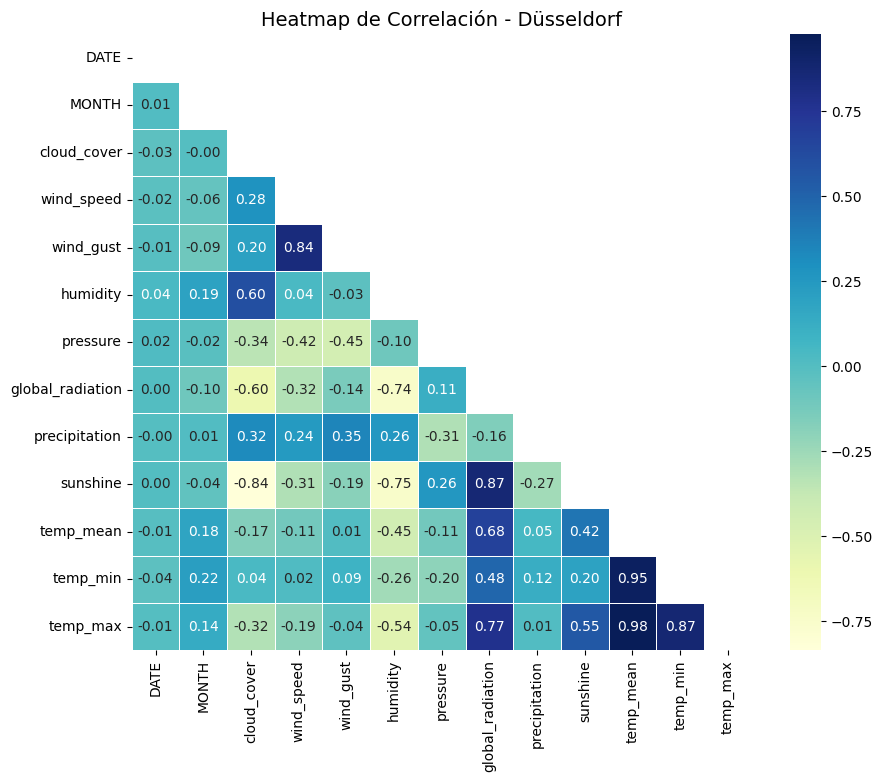

In [65]:
# Seleccionar solo columnas numéricas
df = df_Düsseldorf.select_dtypes(include=['number'])

# Calcular la matriz de correlación
corr_matrix = df.corr()

# Crear una máscara para ocultar la parte superior del triángulo
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Configurar la figura
fig, ax = plt.subplots(figsize=(10, 8))

# Graficar el heatmap
sns.heatmap(corr_matrix, cmap="YlGnBu", annot=True, mask=mask, fmt=".2f", linewidths=0.5, ax=ax)

# Configurar título
ax.set_title("Heatmap de Correlación - Düsseldorf", fontsize=14)

# Mostrar la gráfica
plt.show()

# 🌧️ Análisis de Correlación con la Precipitación - Düsseldorf  

## 🔹 Variables altamente relacionadas con la precipitación  

### 📈 Correlación Positiva  
✔ **Humedad (`humidity`) → 0.35**  
   - **Mayor humedad → Mayor precipitación**.  
   - La humedad es clave en la formación de lluvias, lo cual es esperado.  

✔ **Velocidad del viento (`wind_speed`) → 0.32**  
   - **Más viento → Más lluvia**.  
   - Puede estar asociado a frentes atmosféricos o tormentas.  

✔ **Ráfagas de viento (`wind_gust`) → 0.24**  
   - **Rachas de viento más fuertes → Más precipitación**.  
   - Se asocia a tormentas o sistemas de baja presión.  

---

### 📉 Correlación Negativa  
✔ **Horas de sol (`sunshine`) → -0.31**  
   - **Más precipitación → Menos sol**.  
   - Días lluviosos suelen ser nublados.  

✔ **Radiación global (`global_radiation`) → -0.16**  
   - **Más radiación solar → Menos lluvia**.  
   - Relación débil pero esperada, ya que más sol implica menos nubes.  

✔ **Presión atmosférica (`pressure`) → -0.26**  
   - **Menor presión → Más lluvia**.  
   - Baja presión suele estar asociada a sistemas de tormenta.  



### 🎯 **Conclusión Final**  
- **Las variables más correlacionadas con la precipitación** son:  
  **Humedad (0.35), viento (0.32) y rachas de viento (0.24)**.  
- **Días lluviosos suelen tener menos sol y menor radiación solar**.  
- **La presión baja favorece la precipitación**.  
- **No hay correlaciones extremadamente altas (>0.5), pero los patrones siguen la lógica meteorológica**.  






Los coeficientes de correlación SON relativamente bajos, lo que sugiere que ninguna variable individual explica de manera fuerte la variabilidad de la precipitación. que puedo hacer?

In [70]:

# Suponiendo que df_Düsseldorf es tu DataFrame y tiene la columna 'precipitation'
def categorize_precipitation(precipitation):
    if precipitation < 0.5:
        return 'Llovizna'
    elif 0.5 <= precipitation < 1.5:
        return 'Lluvia'
    elif 1.5 <= precipitation < 3.0:
        return 'Chubasco - Fuertes'
    elif 3.0 <= precipitation < 6.0:
        return 'Chubasco - Muy fuertes'
    else:
        return 'Chubasco - Torrenciales'

# Aplicar la función de categorización a la columna de precipitación
df_Düsseldorf['precipitation_category'] = df_Düsseldorf['precipitation'].apply(categorize_precipitation)

# Verificar el resultado
print(df_Düsseldorf[['precipitation', 'precipitation_category']].head())


   precipitation precipitation_category
0           0.22               Llovizna
1           0.00               Llovizna
2           0.28               Llovizna
3           0.97                 Lluvia
4           0.00               Llovizna


In [71]:
# Ver la cantidad de cada categoría de precipitación
category_counts = df_Düsseldorf['precipitation_category'].value_counts()

# Mostrar los resultados
print(category_counts)


precipitation_category
Llovizna                  3109
Lluvia                     450
Chubasco - Fuertes          87
Chubasco - Muy fuertes       8
Name: count, dtype: int64
